In [ ]:
import numpy as np
from itertools import product
import matplotlib.pyplot as plt

# loading the required datasets
dataset1 = np.load('/content/drive/MyDrive/hw2_material/hac/dataset1.npy')
dataset2 = np.load('/content/drive/MyDrive/hw2_material/hac/dataset2.npy')
dataset3 = np.load('/content/drive/MyDrive/hw2_material/hac/dataset3.npy')
dataset4 = np.load('/content/drive/MyDrive/hw2_material/hac/dataset4.npy')

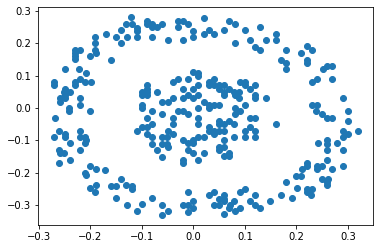

In [ ]:
# initial look at dataset1
plt.scatter(dataset1[:,0],dataset1[:,1], cmap='rainbow')

In [ ]:
def single_linkage(c1, c2):
    """
    Given clusters c1 and c2, calculates the single linkage criterion.
    :param c1: An (N, D) shaped numpy array containing the data points in cluster c1.
    :param c2: An (M, D) shaped numpy array containing the data points in cluster c2.
    :return: A float. The result of the calculation.
    """

    return min(np.linalg.norm(c1_element - c2_element) for c1_element,c2_element in product(c1,c2))

def complete_linkage(c1, c2):
    """
    Given clusters c1 and c2, calculates the complete linkage criterion.
    :param c1: An (N, D) shaped numpy array containing the data points in cluster c1.
    :param c2: An (M, D) shaped numpy array containing the data points in cluster c2.
    :return: A float. The result of the calculation.
    """
    return max(np.linalg.norm(c1_element - c2_element) for c1_element,c2_element in product(c1,c2))



def average_linkage(c1, c2):
    """
    Given clusters c1 and c2, calculates the average linkage criterion.
    :param c1: An (N, D) shaped numpy array containing the data points in cluster c1.
    :param c2: An (M, D) shaped numpy array containing the data points in cluster c2.
    :return: A float. The result of the calculation.
    """
    # dist = []
    # i = 0
    # mesh = np.array(np.meshgrid(c1,c2))
    # combinations = mesh.T.reshape(-1,2)
    # for x in combinations:
    #     dist.append( np.linalg.norm(x[0]-x[1])  )
    #     i += 1
    # return np.sum(np.array(dist)) / i
    gen = (np.linalg.norm(c1_element - c2_element) for c1_element,c2_element in product(c1,c2))
    average = np.mean(np.fromiter(gen,float))
    return average

def centroid_linkage(c1, c2):
    """
    Given clusters c1 and c2, calculates the centroid linkage criterion.
    :param c1: An (N, D) shaped numpy array containing the data points in cluster c1.
    :param c2: An (M, D) shaped numpy array containing the data points in cluster c2.
    :return: A float. The result of the calculation.
    """
    c1_mean = np.mean(c1, axis= 0)
    c2_mean = np.mean(c2, axis=0 )
    # return euclidean(c1_mean, c2_mean)
    return np.linalg.norm(c1_mean-c2_mean)

def hac(data, criterion, stop_length):
    """
    Applies hierarchical agglomerative clustering algorithm with the given criterion on the data
    until the number of clusters reaches the stop_length.
    :param data: An (N, D) shaped numpy array containing all of the data points.
    :param criterion: A function. It can be single_linkage, complete_linkage, average_linkage, or
    centroid_linkage
    :param stop_length: An integer. The length at which the algorithm stops.
    :return: A list of numpy arrays with length stop_length. Each item in the list is a cluster
    and a (Ni, D) sized numpy array.
    """
    # add each element to its own cluster
    clusters = np.array([[example] for example in data])

    while len(clusters) != stop_length:

        # get distance scores for each cluster in clusters list
        lngth = range(len(clusters))
        scores = np.array([ [criterion(clusters[i],clusters[j]), clusters[i],clusters[j] ] for i in lngth for j in lngth if i!=j], dtype=object)

        # get minimum distance pair
        minima = min(scores, key=lambda x: x[0])
        winners_1 = minima[1]
        winners_2 = minima[2]

        # remove pair from clusters list
        clusters = [a for a in clusters if a not in winners_1]
        clusters = [a for a in clusters if a not in winners_2]

        # add their merged cluster into clusters list
        flat_pair = np.concatenate((winners_1, winners_2), axis=0)
        clusters.append(flat_pair)

    return np.array(clusters, dtype=object)


In [ ]:
criterions = [single_linkage, complete_linkage, average_linkage, centroid_linkage]

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:80: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:79: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.


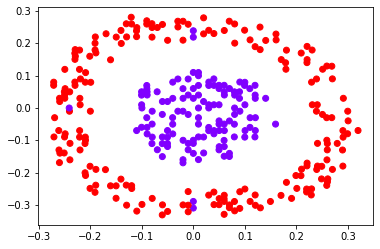

In [ ]:
# for dataset1

clusters = hac(dataset1, single_linkage, 2)

coloring = []
for data in dataset1:
    for j in range(len(clusters)):
        if data in clusters[j]:
            coloring.append(j)

plt.scatter(dataset1[:,0],dataset1[:,1], c=coloring,  cmap='rainbow')

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:80: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:79: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.


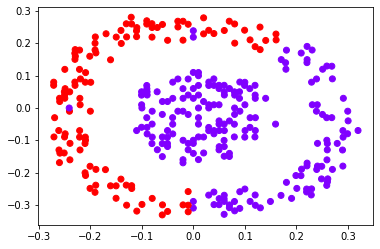

In [ ]:
clusters = hac(dataset1, complete_linkage, 2)

coloring = []
for data in dataset1:
    for j in range(len(clusters)):
        if data in clusters[j]:
            coloring.append(j)

plt.scatter(dataset1[:,0],dataset1[:,1], c=coloring,  cmap='rainbow')

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:80: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:79: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.


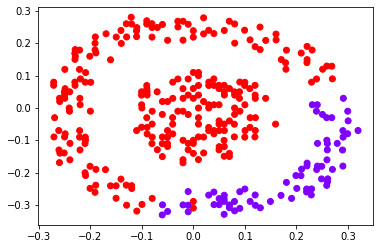

In [ ]:
clusters = hac(dataset1, average_linkage, 2)

coloring = []
for data in dataset1:
    for j in range(len(clusters)):
        if data in clusters[j]:
            coloring.append(j)

plt.scatter(dataset1[:,0],dataset1[:,1], c=coloring,  cmap='rainbow')

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:80: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:79: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.


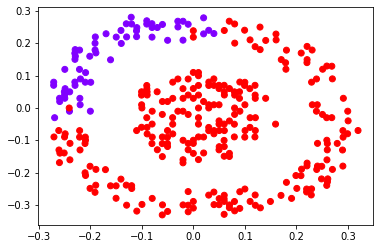

In [ ]:
clusters = hac(dataset1, centroid_linkage, 2)

coloring = []
for data in dataset1:
    for j in range(len(clusters)):
        if data in clusters[j]:
            coloring.append(j)

plt.scatter(dataset1[:,0],dataset1[:,1], c=coloring,  cmap='rainbow')

In [ ]:
clusters = hac(dataset2, single_linkage, 2)

coloring = []
for data in dataset2:
    for j in range(len(clusters)):
        if data in clusters[j]:
            coloring.append(j)

plt.scatter(dataset2[:,0],dataset2[:,1], c=coloring,  cmap='rainbow')

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:80: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:79: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:80: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:79: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.


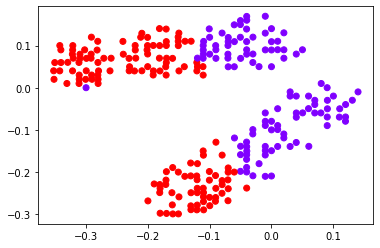

In [ ]:
clusters = hac(dataset2, complete_linkage, 2)

coloring = []
for data in dataset2:
    for j in range(len(clusters)):
        if data in clusters[j]:
            coloring.append(j)

plt.scatter(dataset2[:,0],dataset2[:,1], c=coloring,  cmap='rainbow')

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:80: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:79: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.


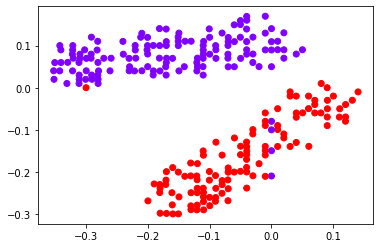

In [ ]:
clusters = hac(dataset2, average_linkage, 2)

coloring = []
for data in dataset2:
    for j in range(len(clusters)):
        if data in clusters[j]:
            coloring.append(j)

plt.scatter(dataset2[:,0],dataset2[:,1], c=coloring,  cmap='rainbow')

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:80: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:79: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.


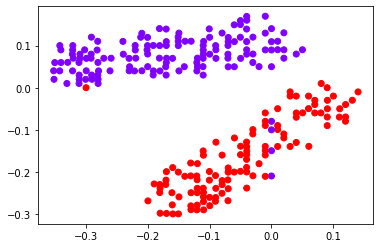

In [ ]:
clusters = hac(dataset2, centroid_linkage, 2)

coloring = []
for data in dataset2:
    for j in range(len(clusters)):
        if data in clusters[j]:
            coloring.append(j)

plt.scatter(dataset2[:,0],dataset2[:,1], c=coloring,  cmap='rainbow')

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:80: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:79: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.


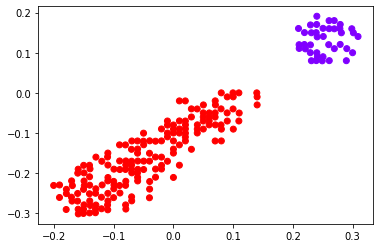